# Exporting charts to SVG and PNG

Export a chart by rendering it to image bytes with `chart.render(fmt)`, then write the bytes wherever they need to go — a file, a web page, an HTTP response. Supported formats include SVG, PNG, and JPG.

In [2]:
from mplchart.chart import Chart
from mplchart.samples import sample_prices
from mplchart.primitives import Candlesticks, Volume, Pane, LinePlot
from mplchart.indicators import SMA, RSI, MACD

## Fetch prices

In [3]:
prices = sample_prices()
prices

,open,high,low,close,volume
date,,,,,
1980-12-12,0.098389,0.098817,0.098389,0.098389,469033600
1980-12-15,0.093684,0.093684,0.093256,0.093256,175884800
1980-12-16,0.086839,0.086839,0.086412,0.086412,105728000
1980-12-17,0.088550,0.088978,0.088550,0.088550,86441600
1980-12-18,0.091118,0.091545,0.091118,0.091118,73449600
...,...,...,...,...,...
2025-11-11,269.809998,275.910004,269.799988,275.250000,46208300
2025-11-12,275.000000,275.730011,271.700012,273.470001,48398000
2025-11-13,274.109985,276.700012,272.089996,272.950012,49602800


## Plot chart with indicators

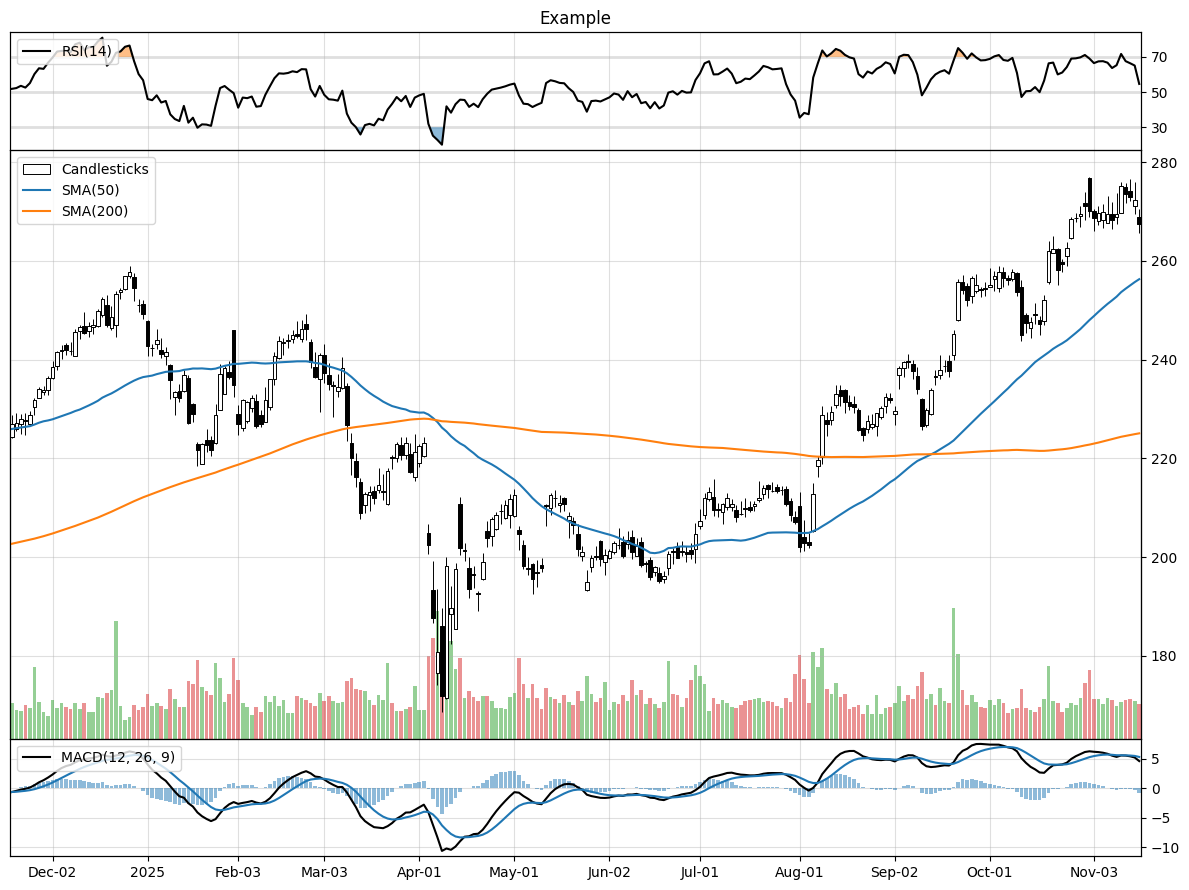

In [4]:
max_bars = 250

chart = Chart(prices, title="Example", max_bars=max_bars).plot(
    Candlesticks(use_bars=False),
    SMA(50),
    SMA(200),
    Volume(),
    Pane("above", yticks=(30, 50, 70)),
    LinePlot(RSI(), overbought=70, oversold=30),
    Pane("below"),
    MACD(),
)

## Render to SVG or PNG

In [4]:
data = chart.render("svg")

print(data[:20] + b"...")


b'<?xml version="1.0" ...'


In [5]:
data = chart.render("png")

print(data[:20] + b"...")

b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x04\xb0...'


## Saving to a file

`render` returns bytes and deliberately stops there — writing them is one line with whatever destination you have:

```python
from pathlib import Path

Path("chart.svg").write_bytes(chart.render("svg"))
Path("chart.png").write_bytes(chart.render("png"))
```

The same bytes embed directly in a web response or an HTML `<img>` tag — see the `Chart.render` entry in the API reference for the format and `dpi` options.